Please enter 6 Aruco marker IDs (0-49) separated by spaces.
Example: 0 1 2 3 4 5
Enter marker IDs: 5 5 5 5 5 5

Successfully generated 'aruco_sheet_4x4_50mm.pdf' with markers: [5, 5, 5, 5, 5, 5]


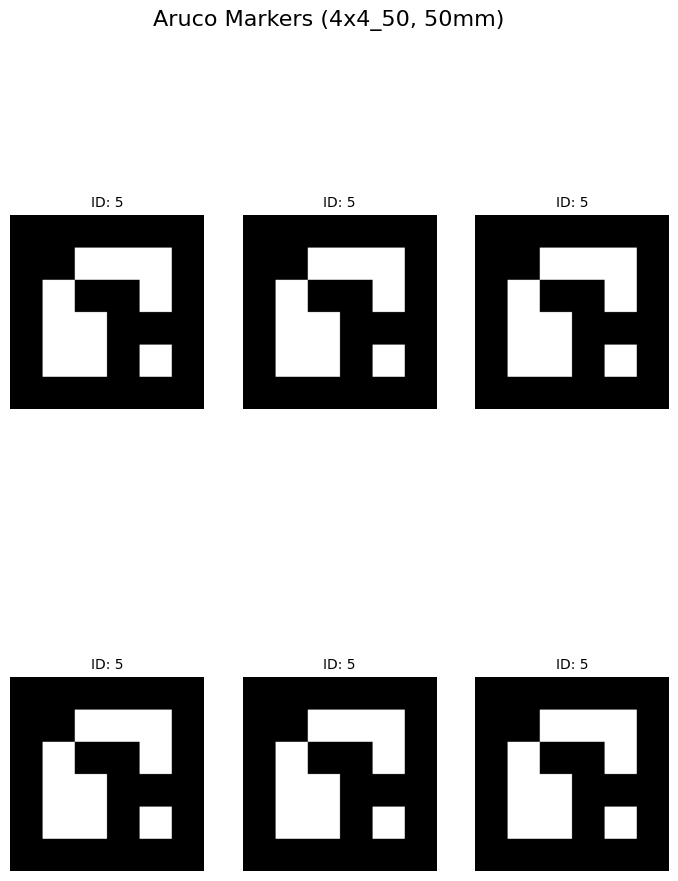

In [ ]:
import cv2
import cv2.aruco as aruco
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration Parameters ---
marker_size_mm = 50  # Size of each Aruco marker in mm
pixels_per_mm = 10  # Resolution for marker image (e.g., 10 pixels per mm)
marker_size_pixels = marker_size_mm * pixels_per_mm
dictionary = aruco.getPredefinedDictionary(aruco.DICT_4X4_50)
num_markers_on_sheet = 6
pdf_filename = 'aruco_sheet_4x4_50mm.pdf'

# --- Get Marker IDs from User ---
print(f"Please enter {num_markers_on_sheet} Aruco marker IDs (0-49) separated by spaces.")
print("Example: 0 1 2 3 4 5")

while True:
    user_input = input("Enter marker IDs: ")
    try:
        marker_ids_str = user_input.split()
        marker_ids = [int(x) for x in marker_ids_str]

        if len(marker_ids) != num_markers_on_sheet:
            print(f"Error: You must enter exactly {num_markers_on_sheet} IDs.")
        elif not all(0 <= mid <= 49 for mid in marker_ids):
            print("Error: All marker IDs must be between 0 and 49 for DICT_4X4_50.")
        else:
            break
    except ValueError:
        print("Invalid input. Please enter numbers separated by spaces.")

# --- Generate and Arrange Markers ---
fig = plt.figure(figsize=(8.5, 11)) # Standard Letter size page for PDF
plt.suptitle(f"Aruco Markers (4x4_50, {marker_size_mm}mm)", fontsize=16)

# Calculate grid for markers
rows = 2
cols = 3

for i, marker_id in enumerate(marker_ids):
    # Generate the marker image
    marker_image = aruco.generateImageMarker(dictionary, marker_id, marker_size_pixels, borderBits=1)

    ax = fig.add_subplot(rows, cols, i + 1)
    ax.imshow(marker_image, cmap='gray')
    ax.set_title(f"ID: {marker_id}", fontsize=10)
    ax.axis('off') # Hide axes

# Removed plt.tight_layout as bbox_inches='tight' in savefig handles layout

# --- Export to PDF ---
plt.savefig(pdf_filename, bbox_inches='tight', pad_inches=1.0) # Increased pad_inches for more margin
print(f"\nSuccessfully generated '{pdf_filename}' with markers: {marker_ids}")
plt.show()